In [ ]:
import pandas as pd
import geopandas as gpd
import shapely.geometry
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

aadt = gpd.read_file(r'C:\projects\IdahoSTDM\ITD_STDM\Data\FromClient\Shapefiles\GIS\AADT_2019.shp')
net = gpd.read_file(r'C:\projects\IdahoSTDM\ITD_STDM\Models\BaseYear\Development\ITDSTDM_05262025\outputs2020\itdasnfinal.shp')
# net = gpd.read_file(r'C:\projects\IdahoSTDM\ITD_STDM\IdahoSTDM\ITDSTDM\outputs2020_newTAZ\itdassignfinal.shp')
#net = gpd.read_file(r'C:\projects\IdahoSTDM\ITD_STDM\IdahoSTDM\ITDSTDM\outputs_2020\itdassignfinal.shp')
# net = net[net['STATE'] == 'Idaho']
net_dl = gpd.read_file(r'C:\projects\IdahoSTDM\ITD_STDM\Data\FromClient\Shapefiles\GIS\double_line_facils.shp')

net2 = net.merge(net[['A', 'B']].rename(columns = {c: f"{c}_R" for c in net.columns}), how = 'left', left_on = ['A', 'B'], right_on = ['B_R', 'A_R']).merge(net_dl[['A', 'B', 'DOUBLE_LIN']], how = 'left', on = ['A', 'B'])
net2['ONEWAY'] = 0
net2.loc[net2['A_R'].isna(), 'ONEWAY'] = 1
net = net2.copy()
net['TVOL'] = net['VOL']

# net['TVOL'] = net['VOLAM'] + net['VOLMD'] + net['VOLPM'] + net['VOLNT']


In [4]:
# Note: this process takes nearly 30 minutes
# aadt_point = aadt[['RouteID', 'FromMeasur', 'ToMeasure', 'AADT', 'PassengerA', 'Commercial']].copy()
# aadt_point['M'] = aadt_point[['FromMeasur', 'ToMeasure']].astype(float).mean(1)
# net['AADT'] = 0
# net['TAADT'] = 0
# net['PAADT'] = 0
# for i, v in net[(~net['TYP'].isin(['Centroid', 'Ramp']))].iterrows():
#     # Why is one direction of freeway joining and not the others
#     cntdf = aadt_point[((aadt_point['RouteID'] == v['WARS_RT_ID']) | (aadt_point['RouteID'].str.replace("A", "D") == v['WARS_RT_ID']) | (aadt_point['RouteID'].str.replace("D", "A") == v['WARS_RT_ID'])) & (((v['WARS_FROM'] > aadt_point['M']) & (aadt_point['M'] > v['WARS_TO'])) | ((v['WARS_FROM'] < aadt_point['M']) & (aadt_point['M'] < v['WARS_TO'])))]['AADT']
#     ccntdf = aadt_point[((aadt_point['RouteID'] == v['WARS_RT_ID']) | (aadt_point['RouteID'].str.replace("A", "D") == v['WARS_RT_ID']) | (aadt_point['RouteID'].str.replace("D", "A") == v['WARS_RT_ID'])) & (((v['WARS_FROM'] > aadt_point['M']) & (aadt_point['M'] > v['WARS_TO'])) | ((v['WARS_FROM'] < aadt_point['M']) & (aadt_point['M'] < v['WARS_TO'])))]['Commercial']
#     pcntdf = aadt_point[((aadt_point['RouteID'] == v['WARS_RT_ID']) | (aadt_point['RouteID'].str.replace("A", "D") == v['WARS_RT_ID']) | (aadt_point['RouteID'].str.replace("D", "A") == v['WARS_RT_ID'])) & (((v['WARS_FROM'] > aadt_point['M']) & (aadt_point['M'] > v['WARS_TO'])) | ((v['WARS_FROM'] < aadt_point['M']) & (aadt_point['M'] < v['WARS_TO'])))]['PassengerA']
#     if cntdf.shape[0] > 0:
#         net.loc[i, 'AADT'] = int(cntdf.values[0].replace(",","")) / (2.0 if net.loc[i, 'ONEWAY'] == 0 or net.loc[i, 'DOUBLE_LIN'] == 1 else 1)
#     if ccntdf.shape[0] > 0:
#         net.loc[i, 'TAADT'] = int(ccntdf.values[0].replace(",","")) / (2.0 if net.loc[i, 'ONEWAY'] == 0 or net.loc[i, 'DOUBLE_LIN'] == 1 else 1)
#     if pcntdf.shape[0] > 0:
#         net.loc[i, 'PAADT'] = int(pcntdf.values[0].replace(",","")) / (2.0 if net.loc[i, 'ONEWAY'] == 0 or net.loc[i, 'DOUBLE_LIN'] == 1 else 1)
counts = pd.read_csv('netcounts.csv')   
net = net.merge(counts, how = 'left', on = ['A', 'B'])

In [5]:
# Check: are these joining properly?
# net.to_file(r'C:\projects\IdahoSTDM\ITD_STDM\IdahoSTDM\ITDSTDM\outputs2020_newTAZ\test_validation.shp')

# VMT Comparison

In [6]:
# VMT comparison
x = net[net['AADT'].fillna(0) > 0].copy()
x['model_vmt'] = x['TVOL'] * x['DIST']
x['obs_vmt'] = x['AADT'] * x['DIST']

x[['obs_vmt', 'model_vmt']].sum().map('{:,.2f}'.format)

obs_vmt      19,790,122.42
model_vmt    30,938,836.71
dtype: object

In [7]:
print(f"{(net['VOL'] * net['DIST']).sum():,.0f}")

107,432,029


# Scatterplot

Slope = 0.8980498049169144, intercept = 715.7857032124418
RMSE: 107.27%


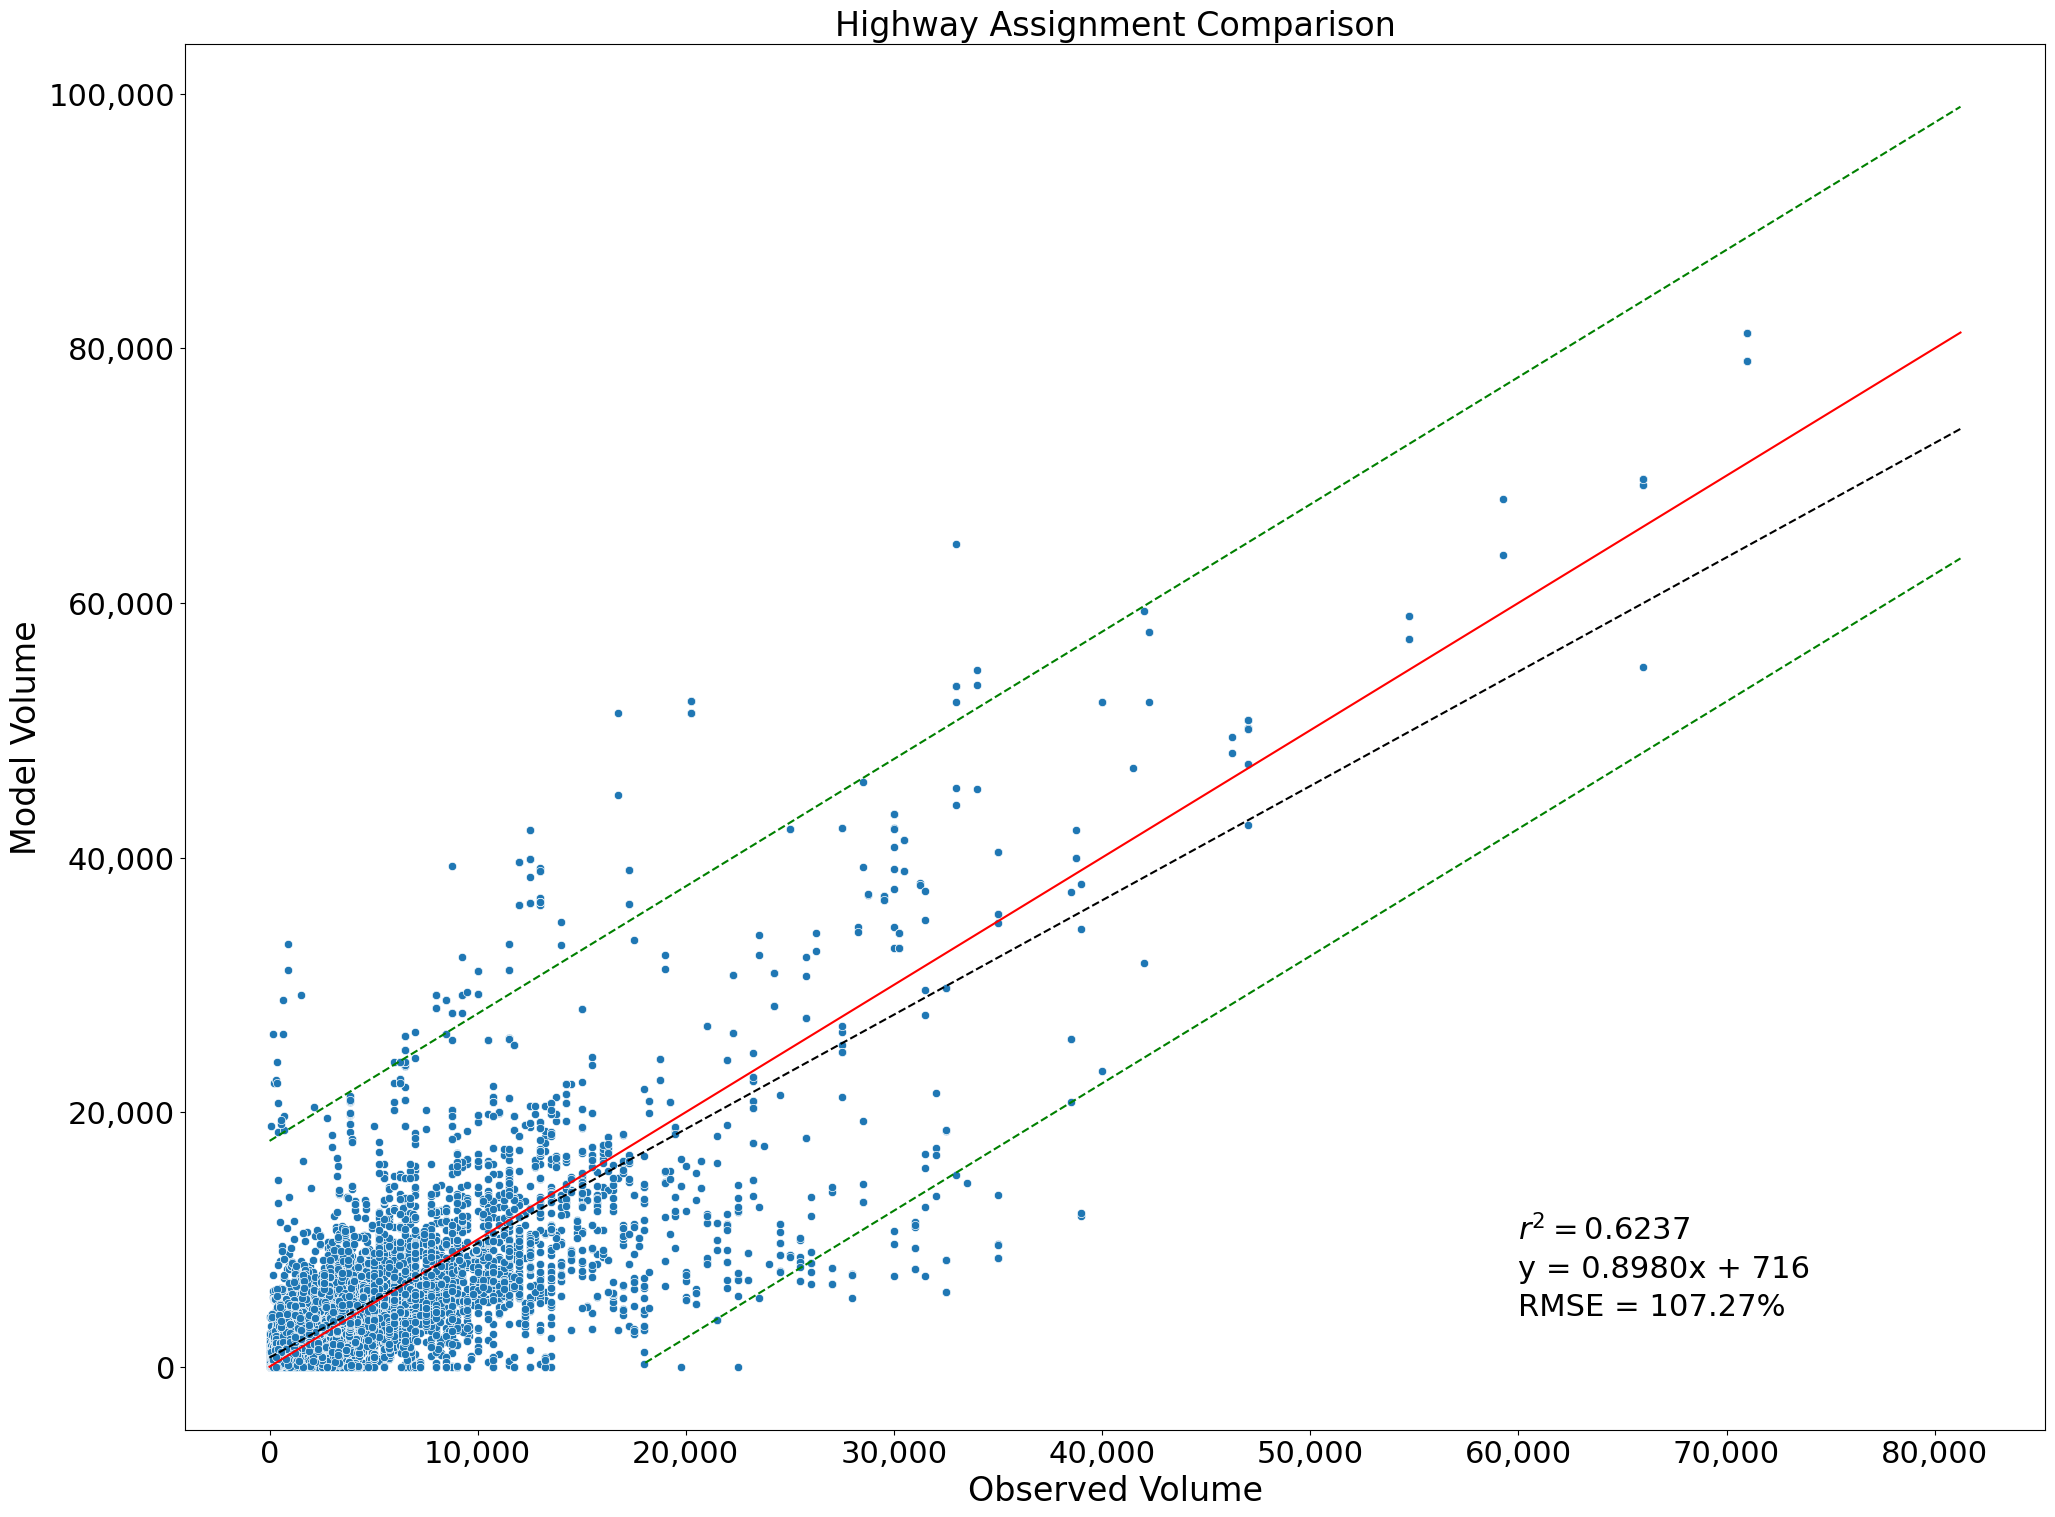

In [8]:
ftype_colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'black', 5: 'black', 6: 'black'}

plot_data = net[net['AADT'] > 0].rename(columns = {'AADT': 'Count', 'TVOL': 'Model'})

m,b = np.polyfit(plot_data['Count'], plot_data['Model'], 1)
poly1d_fn = np.poly1d(np.polyfit(plot_data['Count'], plot_data['Model'], 1)) 
print(f"Slope = {m}, intercept = {b}")

print(f"RMSE: {np.sqrt(((plot_data.Model - plot_data.Count)**2).sum() / plot_data.shape[0]) / (plot_data.Count.sum() / (plot_data.Count.count()-1)):.2%}")

x_pred = np.linspace(0, np.max(np.max(plot_data[['Model', 'Count']])), 100)
x_pred2 = x_pred[x_pred - 3.0 * plot_data.Count.std() > 0]
yy_pred = np.linspace
fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = plot_data, x = 'Count', y = 'Model') #, c = plot_data['FTYPE'].map(ftype_colors))
plt.text(60000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
plt.text(60000, 7000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.text(60000, 4000, f"RMSE = {np.sqrt(((plot_data.Model - plot_data.Count)**2).sum() / plot_data.shape[0]) / (plot_data.Count.sum() / (plot_data.Count.count()-1)):.2%}", fontsize=22)
plt.title(f"Highway Assignment Comparison", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Model Volume', fontsize=24)
plt.xlabel('Observed Volume', fontsize=24)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

Slope = 0.2170655926615283, intercept = 74.46935604989201
RMSE: 238.15%


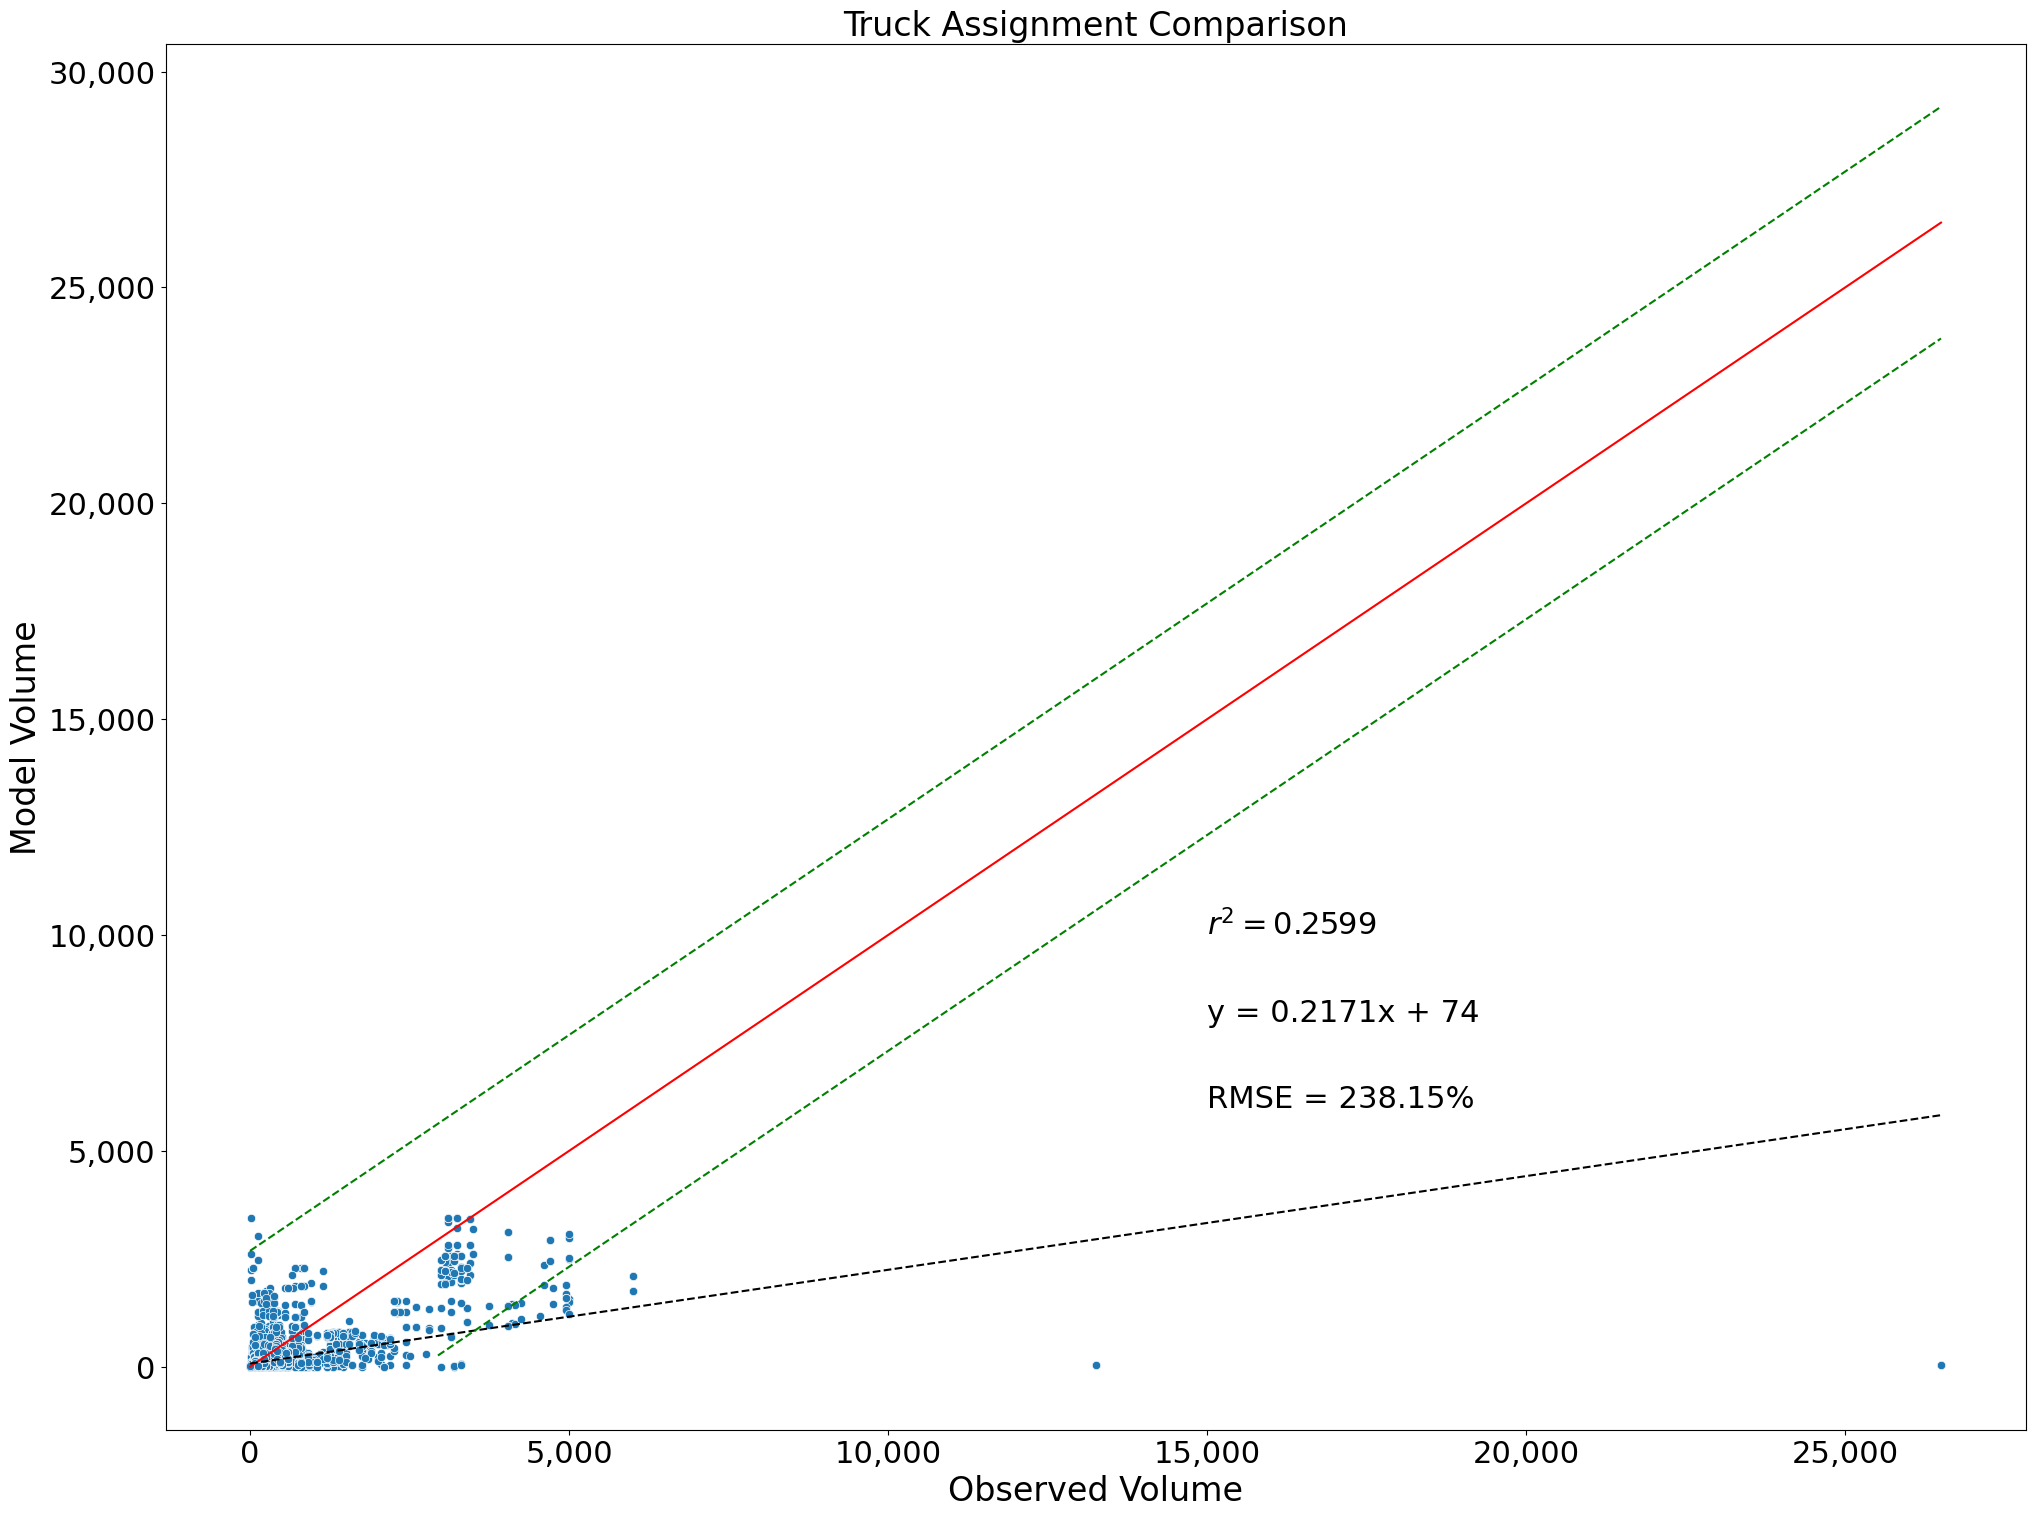

In [9]:
ftype_colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'black', 5: 'black', 6: 'black'}

plot_data = net[net['TAADT'] > 0].rename(columns = {'TAADT': 'Count'})
plot_data['Model'] = plot_data[['SUTAM', 'MUTAM', 'SUTMD', 'MUTMD', 'SUTPM', 'MUTPM', 'SUTNT', 'MUTNT']].sum(1)

m,b = np.polyfit(plot_data['Count'], plot_data['Model'], 1)
poly1d_fn = np.poly1d(np.polyfit(plot_data['Count'], plot_data['Model'], 1)) 
print(f"Slope = {m}, intercept = {b}")

print(f"RMSE: {np.sqrt(((plot_data.Model - plot_data.Count)**2).sum() / plot_data.shape[0]) / (plot_data.Count.sum() / (plot_data.Count.count()-1)):.2%}")

x_pred = np.linspace(0, np.max(np.max(plot_data[['Model', 'Count']])), 100)
x_pred2 = x_pred[x_pred - 3.0 * plot_data.Count.std() > 0]
yy_pred = np.linspace
fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = plot_data, x = 'Count', y = 'Model') #, c = plot_data['FTYPE'].map(ftype_colors))
plt.text(15000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
plt.text(15000, 8000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.text(15000, 6000, f"RMSE = {np.sqrt(((plot_data.Model - plot_data.Count)**2).sum() / plot_data.shape[0]) / (plot_data.Count.sum() / (plot_data.Count.count()-1)):.2%}", fontsize=22)
plt.title(f"Truck Assignment Comparison", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Model Volume', fontsize=24)
plt.xlabel('Observed Volume', fontsize=24)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

Slope = 0.9110558043337678, intercept = 790.7953948754154
RMSE: 116.96%


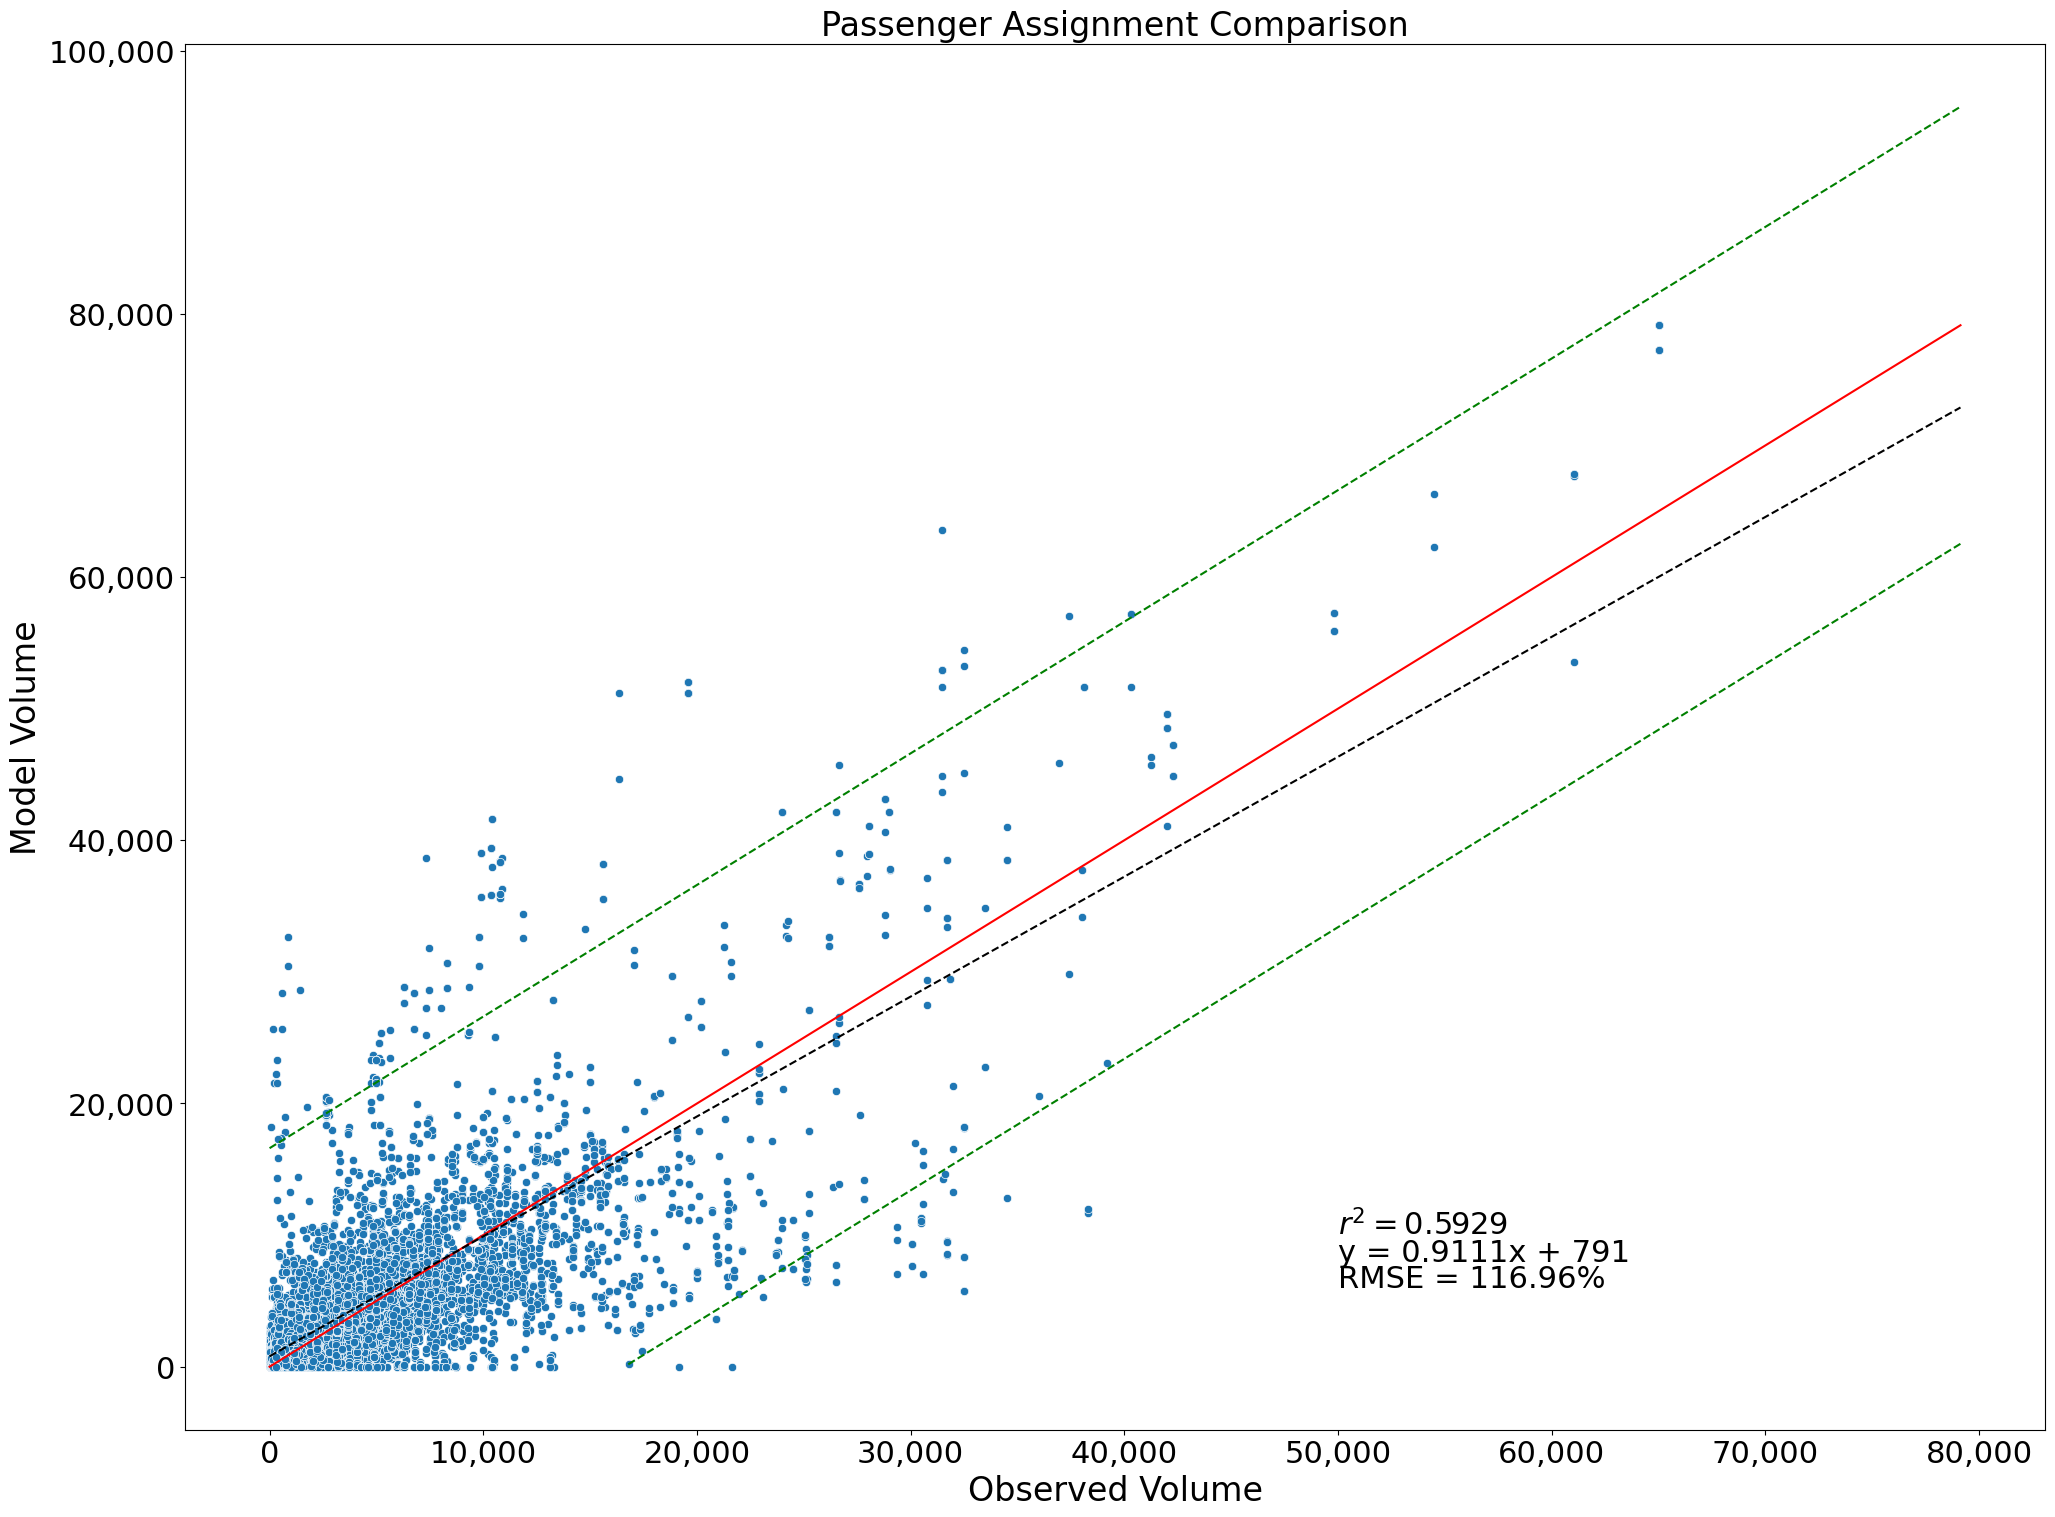

In [10]:
ftype_colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'black', 5: 'black', 6: 'black'}

plot_data = net[net['PAADT'] > 0].rename(columns = {'PAADT': 'Count'})
plot_data['Model'] = plot_data[['SOVAMS', 'HOV2AMS', 'HOV3PAMS', 'EXTAM', 'SOVAML', 'HOV2AML', 'HOV3PAML', 
      'SOVMDS', 'HOV2MDS', 'HOV3PMDS', 'EXTMD', 'SOVMDL', 'HOV2MDL', 'HOV3PMDL', 'SOVPMS', 'HOV2PMS',
      'HOV3PPMS', 'EXTPM', 'SOVPML', 'HOV2PML', 'HOV3PPML', 'SOVNTS', 'HOV2NTS', 'HOV3PNTS', 'EXTNT', 
      'SOVNTL', 'HOV2NTL', 'HOV3PNTL']].sum(1)



m,b = np.polyfit(plot_data['Count'], plot_data['Model'], 1)
poly1d_fn = np.poly1d(np.polyfit(plot_data['Count'], plot_data['Model'], 1)) 
print(f"Slope = {m}, intercept = {b}")

print(f"RMSE: {np.sqrt(((plot_data.Model - plot_data.Count)**2).sum() / plot_data.shape[0]) / (plot_data.Count.sum() / (plot_data.Count.count()-1)):.2%}")

x_pred = np.linspace(0, np.max(np.max(plot_data[['Model', 'Count']])), 100)
x_pred2 = x_pred[x_pred - 3.0 * plot_data.Count.std() > 0]
yy_pred = np.linspace
fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = plot_data, x = 'Count', y = 'Model') #, c = plot_data['FTYPE'].map(ftype_colors))
plt.text(50000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
plt.text(50000, 8000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.text(50000, 6000, f"RMSE = {np.sqrt(((plot_data.Model - plot_data.Count)**2).sum() / plot_data.shape[0]) / (plot_data.Count.sum() / (plot_data.Count.count()-1)):.2%}", fontsize=22)
plt.title(f"Passenger Assignment Comparison", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Model Volume', fontsize=24)
plt.xlabel('Observed Volume', fontsize=24)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

In [11]:
net['diff'] = net['TVOL'] - net['AADT']
net['adiff'] = (net['TVOL'] - net['AADT']).abs()
net['rms_diff'] = np.sqrt((net['TVOL'] - net['AADT'])**2.0)

net.loc[net['AADT'] == 0, ['diff', 'adiff', 'rms_diff']] = 0

net.to_file(r'C:\projects\IdahoSTDM\ITD_STDM\Models\BaseYear\Development\ITDSTDM_03252025\outputs2020\net_w_cnts.shp')

c:\Users\aditya.gore\.conda\envs\py312\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


C:\Users\aditya.gore\AppData\Local\Temp\6\ipykernel_11388\1478597208.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rmse_table = x.assign(diff = lambda x: (x['Model'] - x['Count']) ** 2).groupby('VG').agg(n = ('Model', 'count'), rmse = ('diff', rmse), cnt = ('Count', np.mean)).assign(pct_rmse = lambda x: 100.0 * x['rmse'] / x.cnt).assign(VG_LIMIT = RMSE_LIMITS).assign(VG_LIMIT2 = RMSE_LIMITS2).assign(VG_LIMIT3 = RMSE_LIMITS3)
C:\Users\aditya.gore\AppData\Local\Temp\6\ipykernel_11388\1478597208.py:16: FutureWarning: The provided callable <function mean at 0x000001EB2F2BA3E0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  rmse_table = x.assign(diff = lambda x: (x['Mode

Overall RMSE: 107.28%


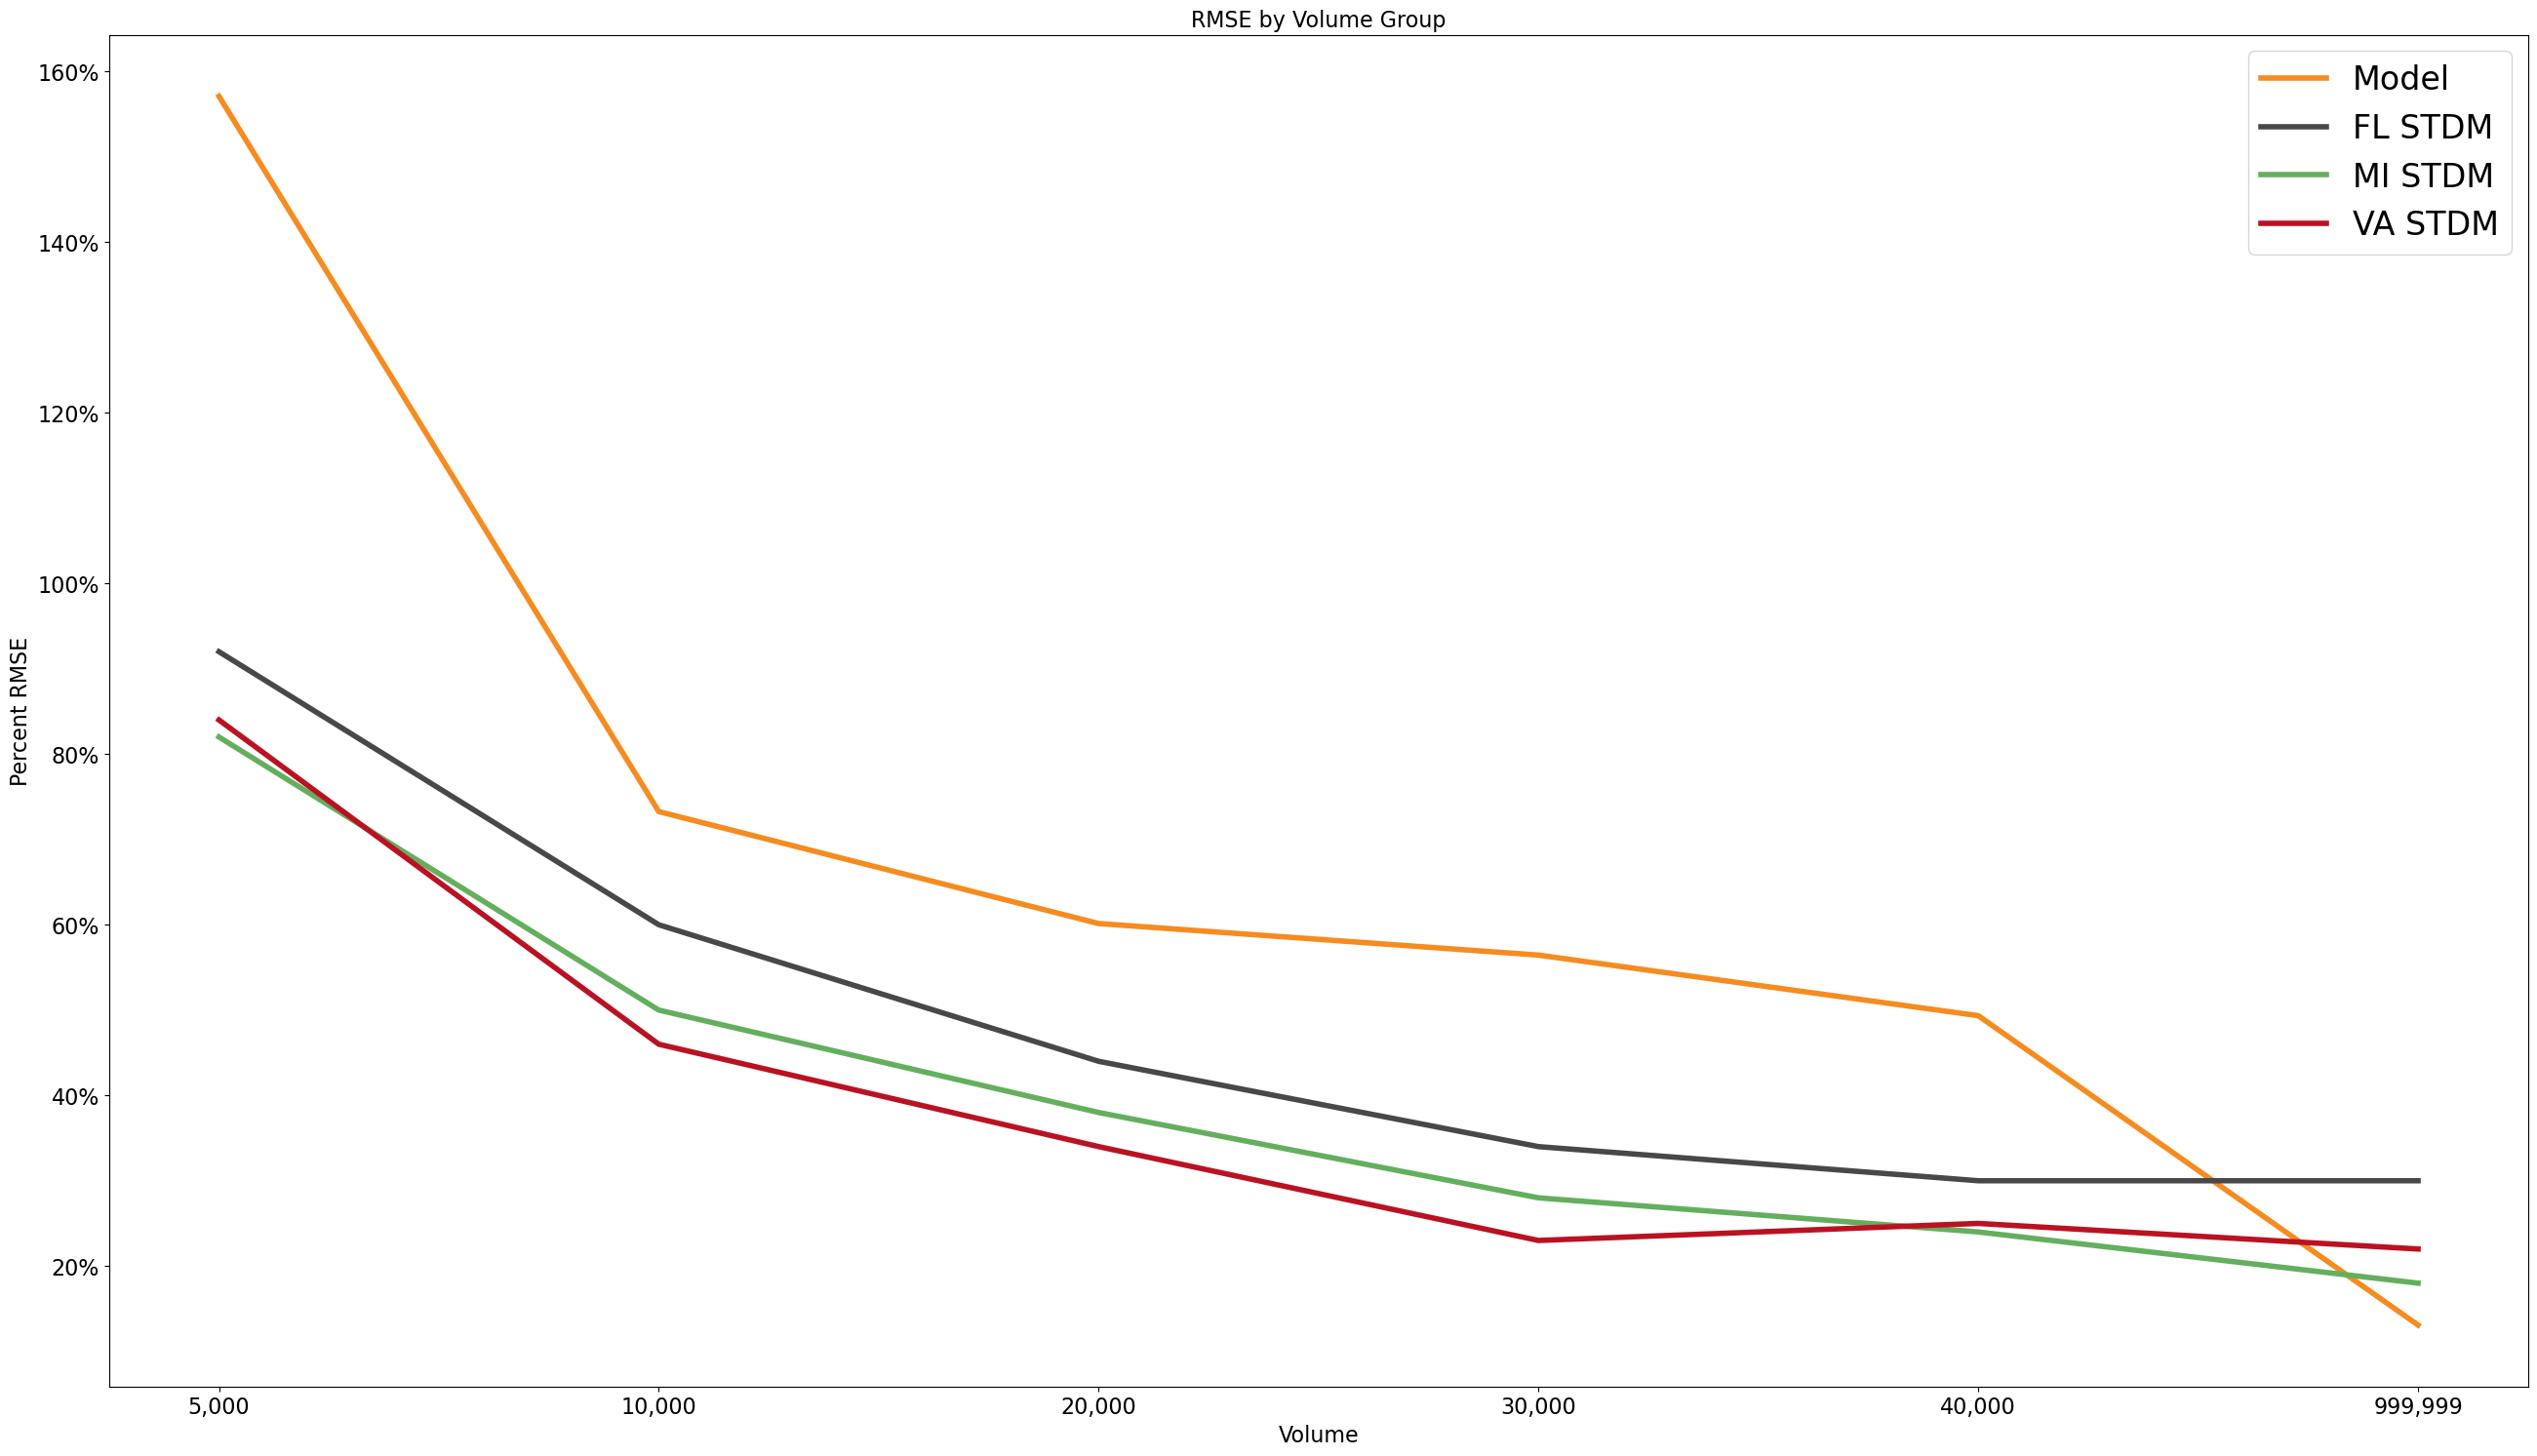

In [12]:
# Based on
VOLUME_GROUPS = [0, 5_000, 10_000, 20_000, 30_000, 40_000, 999_999]

# RMSE_LIMITS = [100, 45, 36, 28, 24, 21, 18, 18] #Ohio Low
# RMSE_LIMITS = [45, 36, 28, 24, 21, 21, 18, 12] # Ohio High
RMSE_LIMITS = [92, 60, 44, 34, 30, 30] # Florida Acceptable
RMSE_LIMITS2 = [82, 50, 38, 28, 24, 18] # Michigan
RMSE_LIMITS3 = [84, 46, 34, 23, 25, 22] # Virginia

x = net[net['AADT'] > 0].rename(columns = {'AADT': 'Count', 'TVOL': 'Model'})
x['VG'] = pd.cut(x['Count'], VOLUME_GROUPS, labels = np.arange(1, len(VOLUME_GROUPS)))

def rmse(x):
    return((np.sqrt(x.sum() / x.shape[0])))

rmse_table = x.assign(diff = lambda x: (x['Model'] - x['Count']) ** 2).groupby('VG').agg(n = ('Model', 'count'), rmse = ('diff', rmse), cnt = ('Count', np.mean)).assign(pct_rmse = lambda x: 100.0 * x['rmse'] / x.cnt).assign(VG_LIMIT = RMSE_LIMITS).assign(VG_LIMIT2 = RMSE_LIMITS2).assign(VG_LIMIT3 = RMSE_LIMITS3)

print(f'Overall RMSE: {rmse((x['Model'] - x['Count']) ** 2) / x.Count.mean():,.2%}')

fig, ax = plt.subplots(figsize=(32, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=rmse_table.index, y=rmse_table.pct_rmse / 100.0, ax=ax, color = '#F68B1F', linewidth=4.0, label = 'Model')
sns.lineplot(x=rmse_table.index, y=rmse_table.VG_LIMIT / 100.0, ax=ax, color = '#48484A', linewidth=4.0, label = 'FL STDM')
sns.lineplot(x=rmse_table.index, y=rmse_table.VG_LIMIT2 / 100.0, ax=ax, color = '#63AF5E', linewidth=4.0, label = 'MI STDM')
sns.lineplot(x=rmse_table.index, y=rmse_table.VG_LIMIT3 / 100.0, ax=ax, color = '#BA1222', linewidth=4.0, label = 'VA STDM')
# sns.lineplot(x = x_pred, y = fun2(x_pred), color = 'green')
# sns.lineplot(x = x_pred, y = fun3(x_pred), color = 'green')
# # sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
# sns.scatterplot(data = plot_data, x = 'TOT_COUNT', y = 'TOT_MODEL') #, c = plot_data['FTYPE'].map(ftype_colors))
plt.legend(fontsize = 24)
plt.title(f"RMSE by Volume Group", fontsize=16)
plt.xticks(fontsize=16, ticks = np.arange(1, len(VOLUME_GROUPS)), labels = [f'{x:,.0f}' for x in VOLUME_GROUPS[1:]])
plt.yticks(fontsize=16)
plt.ylabel('Percent RMSE', fontsize=16)
plt.xlabel('Volume', fontsize=16)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:.0%}'))

# ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

In [13]:
((net['EXTAM'] + net['EXTMD'] + net['EXTPM'] + net['EXTNT']) * net['DIST']).sum()

2544686.5955366534